In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os


# Load saved simulation data
downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "test.npz")

data = np.load(filename)
print("Available variables in test.npz:")
print(data.files)

Available variables in test.npz:
['nh_values', 'navg', 'output_power', 'g2', 'threshold', 'A', 'Ab', 'B', 'SL_fit_R2']


In [29]:
# Pump parameter
nh = data["nh_values"]

# Required observables
navg = data["navg"]                    # <a†a>_ss
power = data["output_power"]           # kappa*hbar*omega_l*<a†a>
g2 = data["g2"]                        # g^(2)(0)

# Masing threshold
threshold = float(np.asarray(data["threshold"]).squeeze())

# Numerically extracted Scully-Lamb parameters
A = data["A"]
Ab = data["Ab"]
B = data["B"]

# Optional quality measure
R2 = data["SL_fit_R2"] if "SL_fit_R2" in data.files else None

print(f"Number of pump points = {len(nh)}")
print(f"Masing threshold nh* = {threshold:.6f}")

print("\nRanges:")
print(f"<n>_ss : {np.nanmin(navg):.6g} -> {np.nanmax(navg):.6g}")
print(f"Power  : {np.nanmin(power):.6g} -> {np.nanmax(power):.6g}")
print(f"g2(0)  : {np.nanmin(g2):.6g} -> {np.nanmax(g2):.6g}")

if R2 is not None:
    print(f"Minimum SL fit R² = {np.nanmin(R2):.6f}")

Number of pump points = 60
Masing threshold nh* = 0.195460

Ranges:
<n>_ss : 0.00913171 -> 6.34062
Power  : 0.00913171 -> 6.34062
g2(0)  : 0.927269 -> 1.08854
Minimum SL fit R² = 0.995874


In [30]:
idx = np.argsort(nh)

nh = nh[idx]
navg = navg[idx]
power = power[idx]
g2 = g2[idx]

A = A[idx]
Ab = Ab[idx]
B = B[idx]

if R2 is not None:
    R2 = R2[idx]

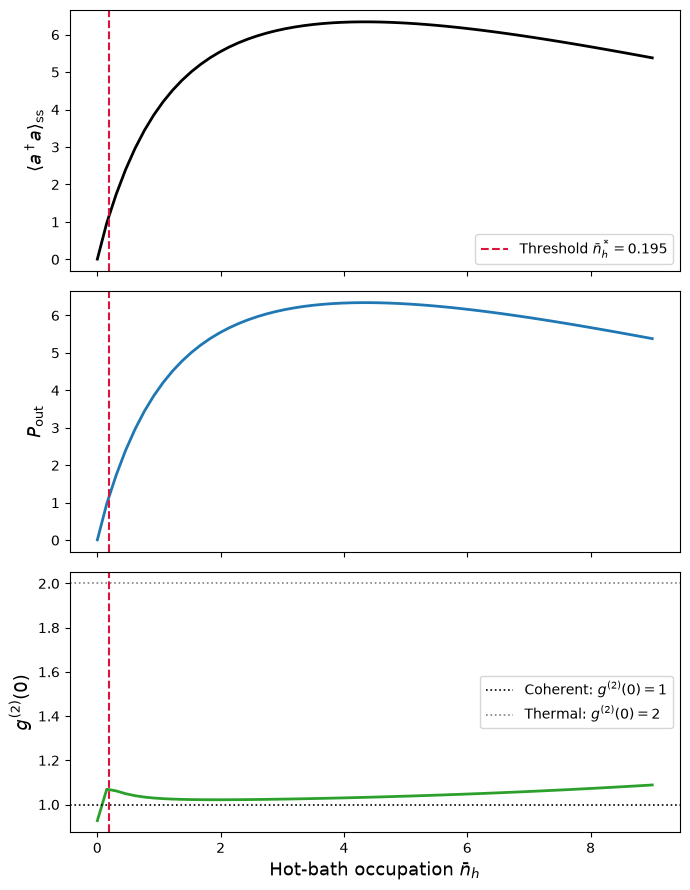

In [31]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(7, 9),
    sharex=True
)

# --------------------------------------------------
# 1. Steady-state photon number
# --------------------------------------------------
ax = axes[0]

ax.plot(
    nh,
    navg,
    color="black",
    lw=2
)

ax.axvline(
    threshold,
    color="crimson",
    ls="--",
    lw=1.5,
    label=fr"Threshold $\bar n_h^*={threshold:.3f}$"
)

ax.set_ylabel(
    r"$\langle a^\dagger a\rangle_{\rm ss}$",
    fontsize=13
)

ax.legend(frameon=True)


# --------------------------------------------------
# 2. Output power
# --------------------------------------------------
ax = axes[1]

ax.plot(
    nh,
    power,
    color="tab:blue",
    lw=2
)

ax.axvline(
    threshold,
    color="crimson",
    ls="--",
    lw=1.5
)

ax.set_ylabel(
    r"$P_{\rm out}$",
    fontsize=13
)



# --------------------------------------------------
# 3. g2(0)
# --------------------------------------------------
ax = axes[2]

ax.plot(
    nh,
    g2,
    color="tab:green",
    lw=2
)

# Coherent field
ax.axhline(
    1.0,
    color="black",
    ls=":",
    lw=1.2,
    label=r"Coherent: $g^{(2)}(0)=1$"
)

# Thermal field
ax.axhline(
    2.0,
    color="gray",
    ls=":",
    lw=1.2,
    label=r"Thermal: $g^{(2)}(0)=2$"
)

ax.axvline(
    threshold,
    color="crimson",
    ls="--",
    lw=1.5
)

ax.set_xlabel(
    r"Hot-bath occupation $\bar n_h$",
    fontsize=13
)

ax.set_ylabel(
    r"$g^{(2)}(0)$",
    fontsize=13
)

ax.legend(frameon=True)

plt.tight_layout()

plt.show()

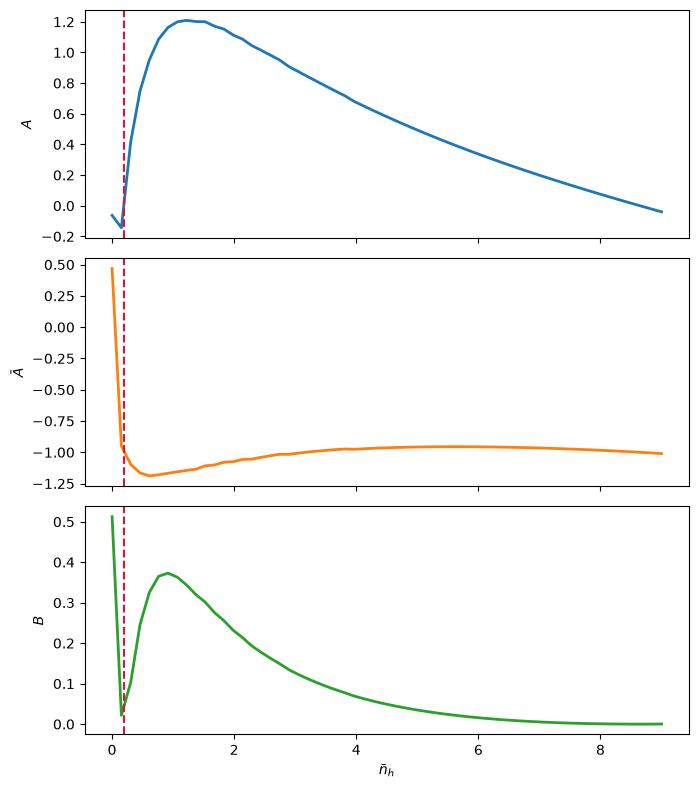

In [32]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(7, 8),
    sharex=True
)

# A
axes[0].plot(
    nh,
    A,
    lw=2,
    color="tab:blue"
)

axes[0].set_ylabel(r"$A$")

# Abar
axes[1].plot(
    nh,
    Ab,
    lw=2,
    color="tab:orange"
)

axes[1].set_ylabel(r"$\bar A$")

# B
axes[2].plot(
    nh,
    B,
    lw=2,
    color="tab:green"
)

axes[2].set_ylabel(r"$B$")
axes[2].set_xlabel(r"$\bar n_h$")

for ax in axes:
    ax.axvline(
        threshold,
        color="crimson",
        ls="--",
        lw=1.5
    )
    

plt.tight_layout()

plt.show()

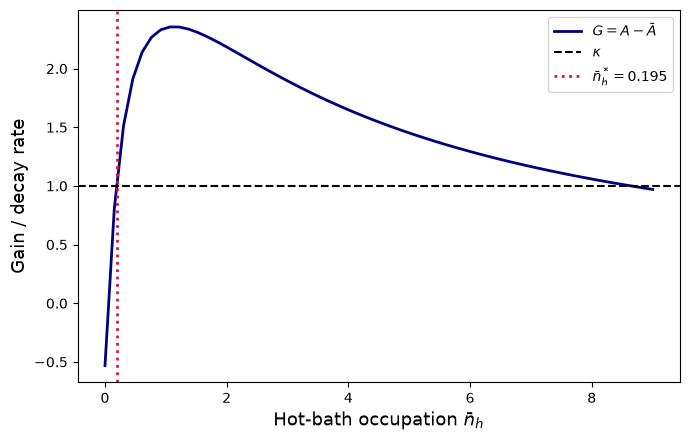

In [33]:
# Net Scully-Lamb gain
G = A - Ab

# kappa = 1 in the simulation
kappa = 1.0

plt.figure(figsize=(7, 4.5))

plt.plot(
    nh,
    G,
    color="navy",
    lw=2,
    label=r"$G=A-\bar A$"
)

plt.axhline(
    kappa,
    color="black",
    ls="--",
    lw=1.5,
    label=r"$\kappa$"
)

plt.axvline(
    threshold,
    color="crimson",
    ls=":",
    lw=2,
    label=fr"$\bar n_h^*={threshold:.3f}$"
)

plt.xlabel(
    r"Hot-bath occupation $\bar n_h$",
    fontsize=13
)

plt.ylabel(
    r"Gain / decay rate",
    fontsize=13
)

plt.legend(frameon=True)

plt.tight_layout()
plt.show()